## Предсказание оттока пользователей банка

В данной работе мы рассмотрим типовую задачу **предсказания оттока** пользователей (*Churn Prediction*). Будем использовать [датасет банковских пользователей](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers).

Датасет имеет следующие поля:

Поле | Значение
-----|---------
CLIENTNUM | Уникальные идентификатор клиента
Attrition_Flag | Признак того, что клиент покинул банк
Customer_Age | Возраст
Gender | Пол
Dependent_count | Число зависимых членов семьи
Education_Level | Уровень образования
Marital_Status | Семейный статус
Income_Category | Уровень годового дохода
Card_Category | Тип кредитной карты
Months_on_book | Время сотрудничества с банком (мес)
Total_Relationship_Count | Общее число продуктов у клиента
Months_Inactive_12_mon | Число неактивных месяцев за последний год
Contacts_Count_12_mon | Число контактов за последний год
Credit_Limit | Кредитный лимит на карте
Total_Revolving_Bal | Общий активный баланс на карте
Avg_Open_To_Buy | Разница между кредитным лимитом по карте и текущим балансом, среднее за последний год
Total_Amt_Chng_Q4_Q1 | Изменение суммы транзакций за год (Q4 на Q1)
Total_Trans_Amt | Сумма транзакций за год
Total_Trans_Ct | Общее число транзакций за год
Total_Ct_Chng_Q4_Q1 | Изменение количества транзакций за год (Q4 на Q1)
Avg_Utilization_Ratio | Объем средств клиента делённый на кредитный лимит (в %)

Требуется предсказать вероятность оттока **Attrition_Flag** для конкретного клиента.


In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("http://www.soshnikov.com/temp/data/BankChurnersProcessed.zip")
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


### Изученный мною в интернете доп. материал

- Что такое несбалансированность задачи классификации? Понял вопрос на примере случаев из медицины, где наиболее интересный класс может быть очень редким. Цена ошибки в определении такого класса может быть очень большой, и тогда непригодность модели по её точности оценивать нельзя. Если чувствительного класса в выборке мало, то и ошибок у модели будет мало, а следовательно, точность упадёт несущественно. На самом деле статья, в которой я это вычитал, довольно объёмная - там как раз и вводят понятия precision, recall, рекомендованные в задании 1. Бонус, говорят про кривую PR AUC и F1-score, принцип которых мне на момент написания текста совсем не понятен.
- Страничка датасета на кеггле для верной интерпретации параметров.
- Размышления с дипсиком
- Мнение Фёдора Наприенко по части экономического поведения. Я просто привык с ним советоваться по поводу интерпретации подобных вещей...

### Этап 1: Предварительный анализ данных

* Посмотрите, какой процент данных соответствует оттекающим клиентам, а какой - стабильным. Насколько такая задача классификации является сбалансированной?

> Несбалансированность датасета означает, что нам необходимо смотреть на precision и recall в качестве метрик, поскольку высокая точность не будет означать, что получившаяся модель делает хорошие предсказания.

* Изучите данные подробнее и посмотрите, есть ли в данных пропуски. Если да - решите, что с ними делать.
* Постройте графики средних значений по всем показателям отдельно для оттекающих и остающихся клиентов и сделайте вывод, какие параметры больше всего влияют на отток.
* Подумайте, какие смысловые атрибуты имеет смысл добавить в датасет. Например, средний размер транзакции за год (`Total_Trans_Amt`/`Total_Trans_Ct`).
* Для того чтобы посмотреть влияние возраста на отток клиентов, можно построить гистограмму возрастов отдельно для оттекающих и не оттекающих клиентов и посмотреть, есть ли разница. То же самое можно проделать для других числовых признаков.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [3]:
stable = len(df[df['Attrition_Flag'] == 'Existing Customer'])
attrited = len(df[df['Attrition_Flag'] == 'Attrited Customer'])
print(stable, (stable/(stable+attrited)), attrited, (attrited/(stable+attrited)), len(df['Attrition_Flag']))

8500 0.8393403772094401 1627 0.1606596227905599 10127


всё-таки это несбалансированная задача, обычный accuracy нам не подойдёт(

посмотрим на пропуски в данных, на которые указывает задание

In [4]:
for i in df.columns:
    print(i, any(df[i].isna().values))

for i in df.columns:
    print(i, df[i].unique())

CLIENTNUM False
Attrition_Flag False
Customer_Age False
Gender False
Dependent_count False
Education_Level False
Marital_Status False
Income_Category False
Card_Category False
Months_on_book False
Total_Relationship_Count False
Months_Inactive_12_mon False
Contacts_Count_12_mon False
Credit_Limit False
Total_Revolving_Bal False
Avg_Open_To_Buy False
Total_Amt_Chng_Q4_Q1 False
Total_Trans_Amt False
Total_Trans_Ct False
Total_Ct_Chng_Q4_Q1 False
Avg_Utilization_Ratio False
CLIENTNUM [768805383 818770008 713982108 ... 716506083 717406983 714337233]
Attrition_Flag ['Existing Customer' 'Attrited Customer']
Customer_Age [45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27]
Gender ['M' 'F']
Dependent_count [3 5 4 2 0 1]
Education_Level ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Marital_Status ['Married' 'Single' 'Unknown' 'Divorced']
Income_Category ['$60K - $80K' 

никаких nan значений нет

а вот значения из серии Unknown - да. У Education_Level, Marital_Status, Income_Category.

### Рассуждение

Заданием на нас наложены оковы - необходимо разобраться, как быть с пропусками. Но, имхо, корректнее спросить для начала - а критичны ли нам пропуски? Давать однозначный ответ на мой вопрос можно только после того, как мы проведём множество экспериментов и отследим чёткое влияние изменения параметра на конечный факт - уход клиента. Я осмелюсь выдвинуть предположения о важности параметров на факт окончания сотрудничества без экспериментов, только на рассуждении.

#### Education_Level

В этом блоке было очень много текста с моим рассуждением о том, как уровень образования влияет на экономическое поведение человека. Я успел выйти и на идею об умении управлять задолженностью, а значит образованные люди могут вообще не попасть в случаи, когда они не смогут из-за неё уйти. Успел порассуждать и о том, что более образованные могут оставаться в банке, потому что они понимают выгоду. А может тогда у них тариф круче или кол-во продуктов отличается?

Но на ключевой вопрос - уйдёт клиент или нет - моё рассуждение так и не дошло. Уровень образования, по моему мнению, может объяснить значение отдельных колонок в той же строчке таблицы, а они с каким-то шансом объяснят нам - уйдёт клиент или нет? Но ведь это непрямая тогда связь.

Исходя из этого, строчки, где образование не указано, удалять не надо. И менять его никак не надо. Ведь значение конкретно этого фактора, опять же именно согласно моему рассуждению, или никакое, или незначительное, или обусловлено совсем не им, а параметром, который идёт вместе.

#### Marital_Status

Не усложняя рассуждение нынешним трендом на то, что вступление в брак совсем не гарантирует рост Dependent_count, скажем прямо - действительно, брак часто означает то, что человек в своём экономическом поведении более ограничен, если бы был холост. Т.е., клиент скорее останется. Опять же нюанс. Не потому что он насильно в банке, не потому что условия отдельного тарифа могут быть выгодными, а потому что клиент в браке не любит изменений, даже таких как обыкновенная смена банка.

Погодите, погодите. А разве это не то же самое, что и Education_Level? "Обусловлено совсем не им, а параметром, который идёт вместе". Нет, не всегда Dependent_count нужен для того, чтобы человеку в браке прийти к нелюбви к изменениям => понижению риска ухода от банка. Давайте так, даже если у вас семья, где вы и партнёр, значит вы скорее всего делите одну крышу и быт. То есть в ваши прогнозы добавляются новые переменные, которые мы обобщим как поведение партнёра. И у вас, в отличие от холостого, гораздо больше тех исходов, когда вы не разорвёте отношения с банком из-за опасения последствий на вашего, скорее всего, любимого партнёра.

Исходя из этого, строчки, где нет семейного положения, удалять не надо, но нужно определённым образом менять. Например, если у клиента есть Dependent_count, то будем ставить ему Married. Разумеется, есть разведённые люди с детьми. Но давайте позволим себе такую грубость, контекст задачи позволяет.

#### Income_Category

Эта переменная отображает категорию доходов. Отвязываясь от тяжёлых экономических размышлений про стоимость денег и инфляции, параметр показывает покупательскую способность и вероятную задолженность. А на вероятность расторжения отношений влияет? Ну вот чёрт его знает. Я бы подумал в том же стиле, что и с параметром выше,- как изменение параметра смогло бы повлиять на поддержание сотрудничества? Если доход упадёт, то резон пользоваться кредиткой может как вырасти, так и упасть - окончательное решение будет принято под воздействием скорее других факторов, будь то Dependent_Count, Marital_Status и т.д.

Не мусоля дальше, скорее всего нет. Есть параметры важнее. Они могут тащить за собой этот параметр в паре. Я предлагаю ничего не делать с этой строчкой.

### Ответ нейронки

После моего личного рассуждения, которое я выкладывал и форматировал 3 часа, попутно отвлекаясь на совсем недавно приобретённую террарию, я решил скормить страницу с этим датасетом на кегле дипсику и попросил его пробежаться по каждой из колонке и дать свою оценку важности в нашем вопросе. Наши мысли с ним почти совпали. У меня с ним противоречие по поводу Marital_Status, который он оценил не так важно, как я. Ну и ладно, я от своего мнения отказываться не собираюсь. Можно поступить как Бажаев А.В. и сказать, что "это очередной нейрослоп", закрепить это общественным мнением о пузыре ИИ, а потом надеть шапку из фольги и потратить всю свою зп на звёздочки тг, которые я потом единоразово закину на смешной пост из Кормушки.

In [5]:
# btw это грубое упрощение, но в контексте простительно
# UPD после гистограмм: это писец как непростительно грубо, но нам можно
df['Marital_Status'] = np.where(df['Dependent_count'] > 0, 'Married', df['Marital_Status'])
df['Marital_Status'] = np.where(((df['Dependent_count'] == 0) & (df['Marital_Status'] == 'Unknown')), 'Single', df['Marital_Status'])
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Married,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Married,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Married,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Married,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Married,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [6]:
st = df[df['Attrition_Flag'] == 'Existing Customer']
att = df[df['Attrition_Flag'] == 'Attrited Customer']

Теперь можно посмотреть распределение значений параметров по ушедшим и действующим клиентам, чтобы отыскать какие-то явные отличия.

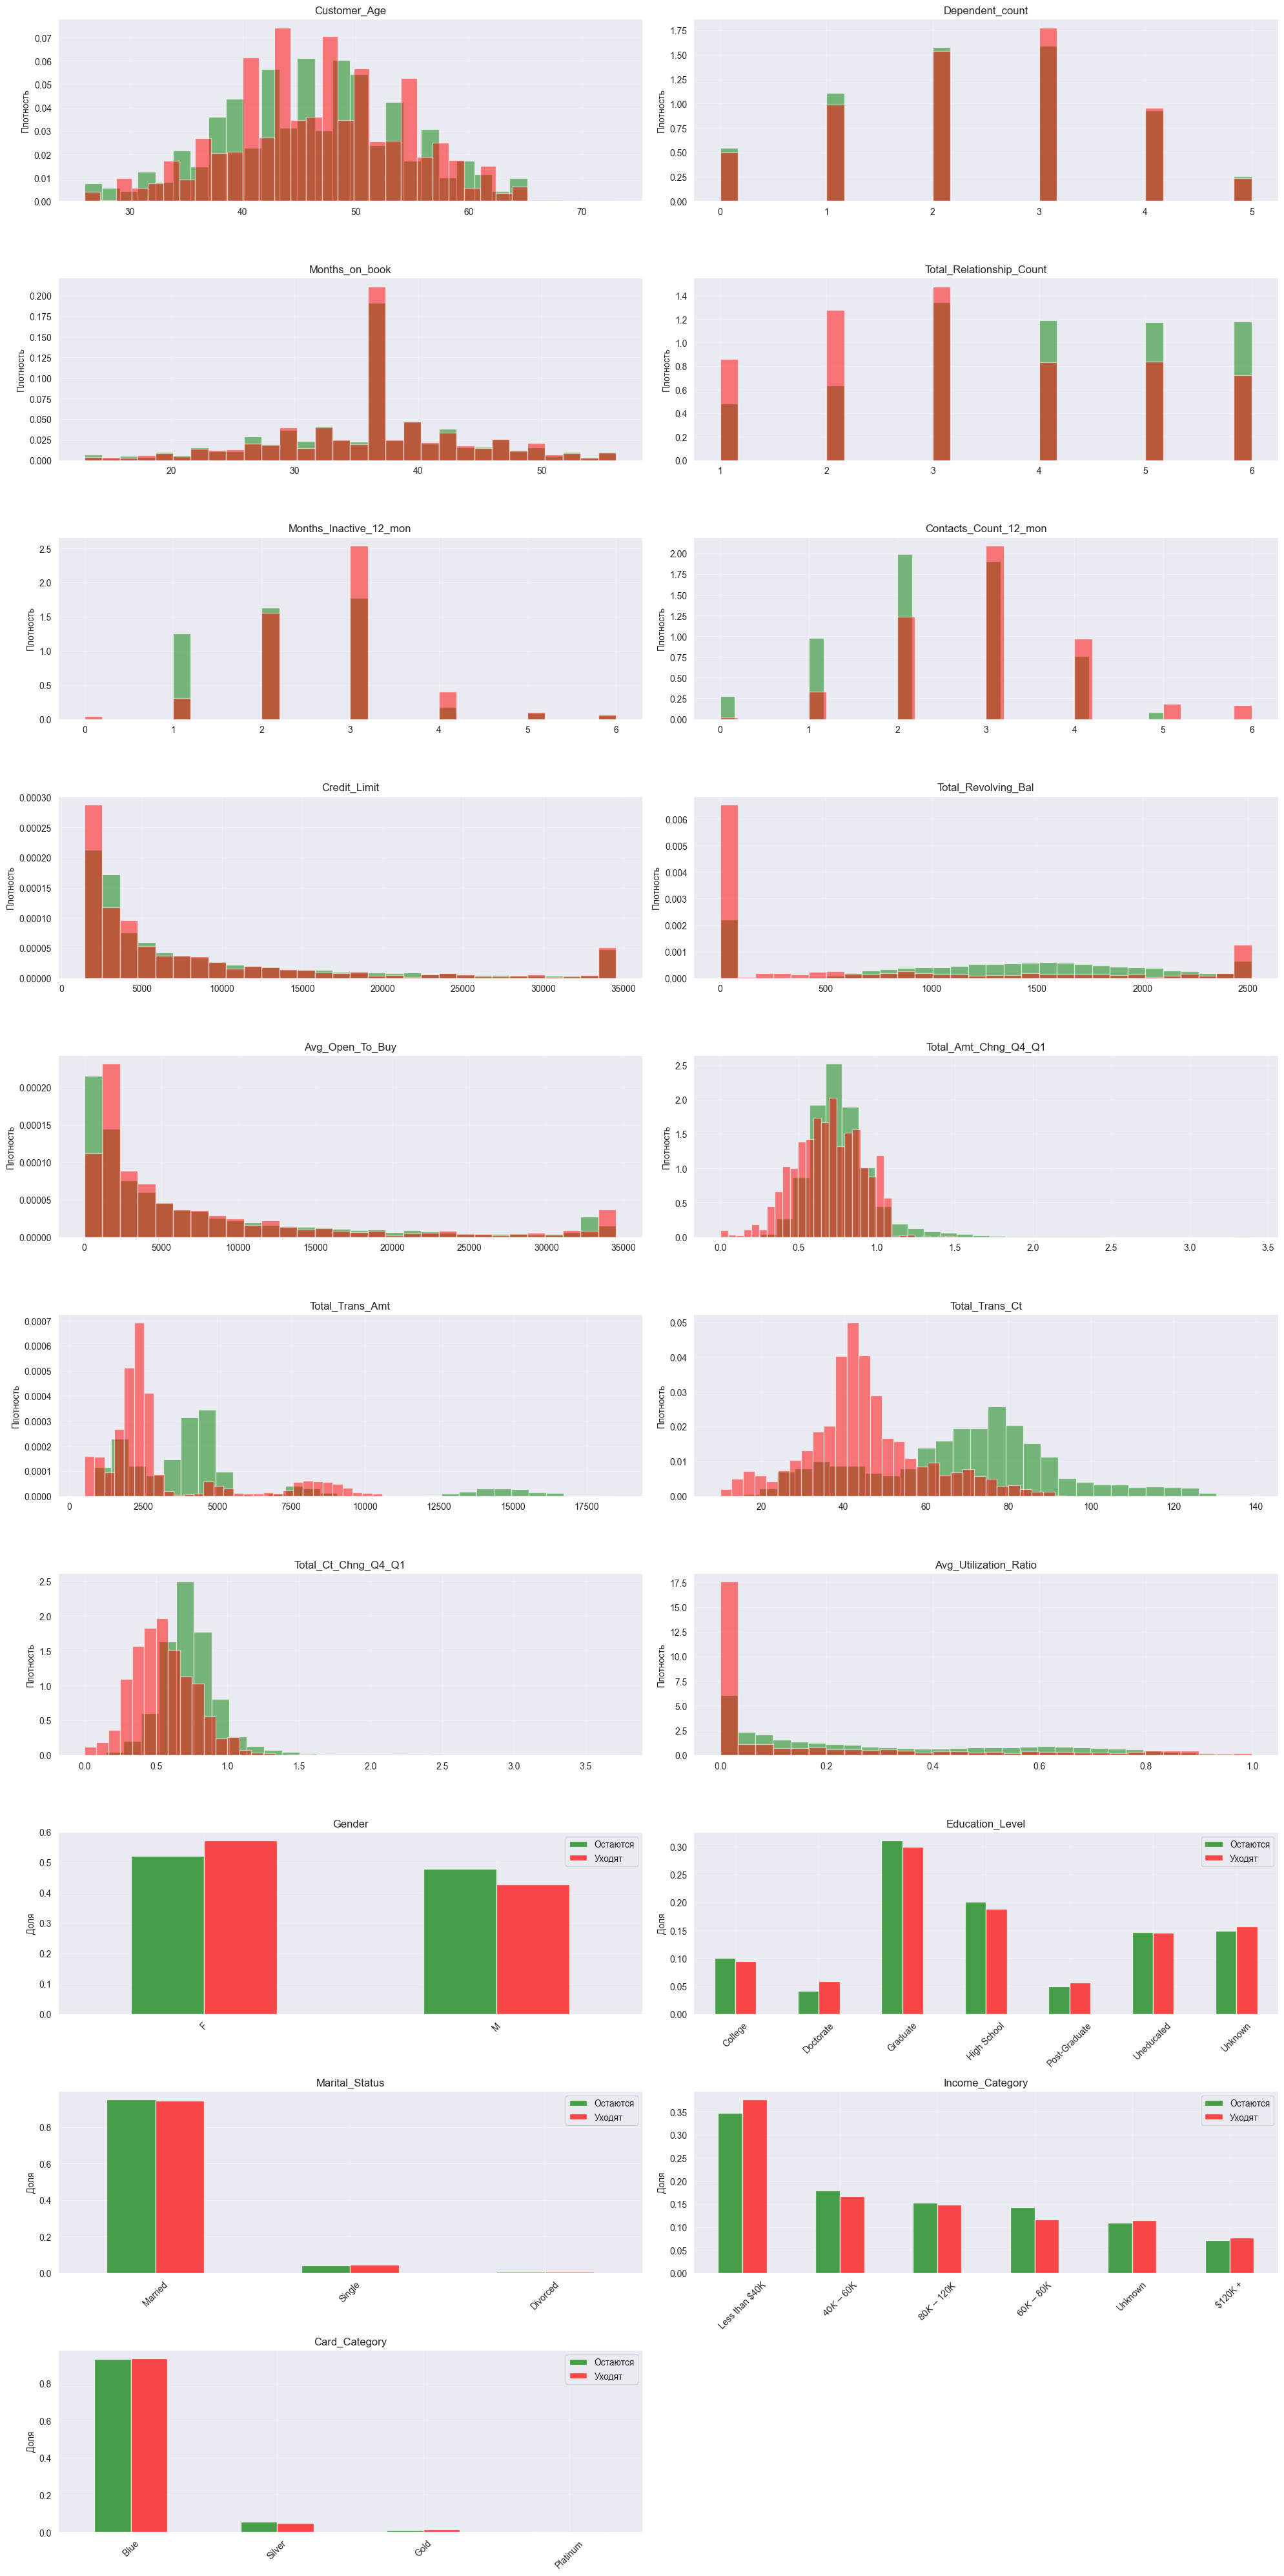

In [7]:
from matplotlib import pyplot as plt


numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

if 'Attrition_Flag' in numeric:
    numeric.remove('Attrition_Flag')
if 'Attrition_Flag' in categorical:
    categorical.remove('Attrition_Flag')
if 'CLIENTNUM' in numeric:
    numeric.remove('CLIENTNUM')


all_cols = numeric + categorical
n_cols = 2
n_rows = (len(all_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(all_cols):
    ax = axes[i]

    if col in numeric:
        df[df['Attrition_Flag'] == 'Existing Customer'][col].hist(
            alpha=0.5, bins=30, label='Остаются', ax=ax, color='green', density=True
        )
        df[df['Attrition_Flag'] == 'Attrited Customer'][col].hist(
            alpha=0.5, bins=30, label='Уходят', ax=ax, color='red', density=True
        )
        ax.set_title(f'{col}')

    else:
        existing_counts = df[df['Attrition_Flag'] == 'Existing Customer'][col].value_counts(normalize=True)
        attrited_counts = df[df['Attrition_Flag'] == 'Attrited Customer'][col].value_counts(normalize=True)

        counts_df = pd.DataFrame({
            'Остаются': existing_counts,
            'Уходят': attrited_counts
        }).fillna(0)

        counts_df.plot(kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)

        ax.set_title(f'{col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.legend()

        if not counts_df.empty:
            top_category = counts_df.index[0]
            diff = (counts_df.loc[top_category, 'Уходят'] - counts_df.loc[top_category, 'Остаются']) * 100

    ax.set_ylabel('Доля' if col in categorical else 'Плотность')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

По графику заметим, что кое-где разница в какой-то степени да выходит

### Возраст (Customer_Age)

По гистограмме видно, что распределения ещё существующих клиентов между собой на отрезке возрастов имеют ровно обратные по смыслу распеделения - уходящих людей. Наибольшее распределение мы видим у людей с возрастом в интервале от 40 до 50 лет и характерную горку между 50 и 60 т.е ~55 лет.

Наблюдаем хорошую для банка картину до приближения клиентов к возрасту 30 лет - молодые пользуются кредитками, но к достижению психологической точки тридцатник начинают расторгать отношения в силу переоценки жизненных приоритетов. Двигаясь по возрасту далее мы видим очередные очаги клиентов, хотя к 35 годам тенденция снова переменяется. Пройдя ещё дальше, мы видим однозначное уплотнение по мере того, как клиенты приближаются к 40 годам, но сразу после них мы видим будто бы отвечающее обратно уплотнение ушедших клиентов. Я осмелюсь предположить, что такие американские горки на возрастной шкале происходят не столько из-за конкретной цифры в паспорте, а из-за того, что ключевые события и переломы в жизни людей происходят не единовременно со всеми. То есть, какие-то закономерности, ведущие к решению закрыть кредитку, проходятся по людям волнами. От того и такое распределение.

### Total_relationship_count

Очевидное наблюдение: чем больше у человека продуктов в банке, тем меньше вероятность, что он из него уйдёт. Планка перелома - 3 продукта включительно. При достижении этого числа мы видим преобладание существующих клиентов.

### Monts on book

Когда я посмотрел на этот график, в моей голове окончательно утвердилась мысль - тенденции, которые мы приписываем исходя из распределений существующих клиентов могут совсем ничего не значить. Ведь в реальности, то знание, которое мы можем получить от гистограммы возраста или вот этой - месяцев сотрудничества - могут оказаться либо разными гранями нормы, либо обыкновенным совпадением.

### Насущный вопрос

А что тогда важно? Наверное, нам пора перестать смотреть на факторы, которые могут объяснить экономическое поведение. И сделать очевидную вещь. Посмотреть на само экономическое поведение. Зачем людям нужна кредитка? Чтобы получить ресурсы поверх того, что оин имеют сейчас. Нет пользования деньгами - нет смысла в кредитке. Давайте по чесноку - банку самому вряд ли нужны клиенты, которые не пользуются полученной кредиткой, ведь от них нет процентов.

Мои рассуждения о важности того или иного параметра и/или пропусков в них не бесполезны. Помните я говорил о том, что это слишком глупо думать, мол, люди оставляют кредитку только потому что из-за долгов по ней не могут уйти. Цифры расширили мою гипотезу. Клиенту нужна кредитка ради доп денег. Доп деньги - это долг. Не видим метрик задолженности - значит кредитка не юзается и закрывается (вот это уже подтверждает гистограмма того же Total_Revolving_Bal, которая показывает какой долг уходит на след мес среди уходящих и текущих. Логично, что у ушедших тут почти полное распределение в нуле - люди гасят долг и расторгают отношения.

Кстати размышления про Dependent_Count не оправдались. И Education_Level удивил.

## Итог мучений

Я настрадал стены текста со своими рассуждениями о данных. Выполнил пункты 1 этапа и чуть-чуть залез на второй.


### Этап 2: Векторизация

* Разбейте данные на обучающую и тестовую выборки
* Посмотрите, какие параметры являются категориальными, и для каждого из параметров определите, является ли он номинальным или порядковым.
* Подумайте, какие параметры можно исключить из модели. Например, после вычисления среднего размера транзакции за год, можно ли исключить общий объем и количество транзакций?
* Подумайте, как использовать корреляцию между столбцами для того, чтобы понять, какие признаки можно исключить.
* Используйте `ColumnTransformer` для векторизации всех порядковых и числовых значений и получения векторизованного датасета.


Предположу, что лучше начать со второго и третьего пункта.

Категориальные столбцы - Gender, Education_Level, Income_Category, Marital_Status и Card_Category. Из них порядковые все, кроме Gender и Marital_Status. Эти два номинальные.

Я предлагаю изменить некоторые параметры. Давайте сделаем Usage_Intensity = Avg_Utilization_Ratio * Total_Trans_Ct. От множителей в таблице можно избавиться. Среди параметров оставим те, которые показывают изменение. Они идут со словом Chng - Total_Ct_Chng_Q4_Q1 + Total_Amt_Chng_Q4_Q1. Contacts_Count_12_mon будем так же учитывать - чем больше, тем хуже, обратная аналогия с Total_Relationship_Count. Month_Inactive_12_month тоже нужно учитывать, но будем как-то нормализовать, возможно логарифмируем с основанием < 1.

In [ ]:
# корреляционный анализ ключевых критериев

### Этап 3: Обучение модели

* Обучите несколько моделей машинного обучения (логистическая регрессия, дерево решений, лес решений, SVM) и сравните полученные метрики на тестовой выборке: accuracy, precision, recall
* По возможности проинтерпретируйте полученные модели и сравните результаты с предварительным анализом. Действительно ли те признаки, которые визуально оказывали влияние на результат, учитываются моделью в первую очередь?


### Этап 4: CatBoost

* [Опционально] Посмотрите на библиотеку [CatBoost](https://catboost.ai/) от Яндекс и попробуйте использовать её для решения задачи. Сравните полученные метрики. CatBoost известна тем, что хорошо работает с категориальными данными.
